In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import Verlet_Update, InitialCondition, dt
from scipy.stats import maxwell

In [2]:
class constants:
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    Temperature = 10e-3 # K
    Zmin = -605 # mm
    Zmax = -481 # mm
    Zmid = -544 # mm

CONSTANTS = constants()

# Load Gravity Well

In [3]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


# Functions to make the plot nicer

In [4]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

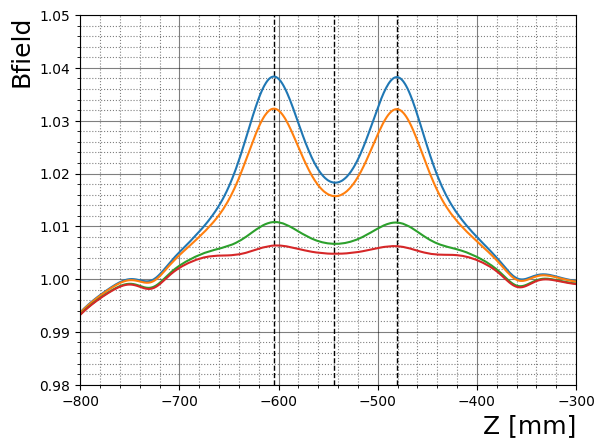

In [5]:
plotter_nicer("Z [mm]", "Bfield")
plt.xlim(-800, -300)
plt.ylim(0.98, 1.05)
plt.axvline(-605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

# Create the 3 segments

In [6]:
# Segment 1,
def segment1(Z,T, ramplength):
    return Bfield_20mT_pregravity(Z) + (Bfield_17mT(Z) - Bfield_20mT_pregravity(Z)) * ( T/ramplength)

# Segment 2,
def segment2(Z,T, ramplength):
    return Bfield_17mT(Z) + (Bfield_5mT(Z) - Bfield_17mT(Z)) * ( T/ramplength)

# Segment 3,
def segment3(Z,T, ramplength):
    return Bfield_5mT(Z) + (Bfield_2p5mT(Z) - Bfield_5mT(Z)) * ( T/ramplength)

# Simulation Setting

In [12]:
nAtoms = 10000
Time = 0

zacceptance_min = -775
zacceptance_max = -325

def annihilated(Z):
    global zacceptance_min, zacceptance_max
    booleano = (Z < zacceptance_min) or (Z > zacceptance_max)
    return booleano

Tramp1     = 10
wait_ramp1 = 10 + Tramp1

Tramp2     = 10 + wait_ramp1
wait_ramp2 = 10 + Tramp2

Tramp3     = 10 + wait_ramp2
wait_ramp3 = 10 + Tramp3

## Define variables for visualization

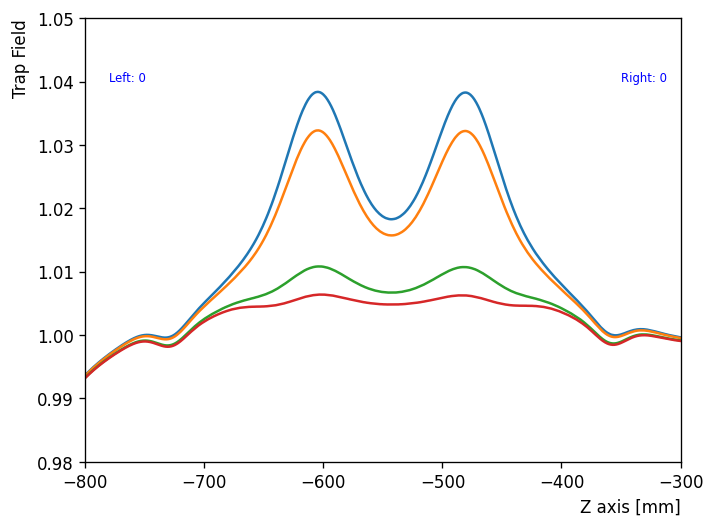

In [8]:
import matplotlib.animation as animation
from matplotlib import rc
from matplotlib import rcParams
from IPython.display import HTML
plt.rcParams['figure.dpi']  = 120  # non 200-300
plt.rcParams['savefig.dpi'] = 120
rc('animation', html='jshtml')   # dice a Matplotlib di rendere l'animazione come HTML/JS

# Imposta il rendering e il limite di embed PRIMA di creare l'animazione
rcParams['animation.html'] = 'jshtml'
rcParams['animation.embed_limit'] = 800.0  # in MB (float)

fig, ax = plt.subplots()

ax.set_xlim(-800, -300)
ax.set_ylim(0.98, 1.05)
ax.set_xlabel("Z axis [mm]", loc = "right")
ax.set_ylabel("Trap Field", loc = "top")

particles_plots = [ax.plot([], [], 'ro', markersize= 2)[0] for _ in range(nAtoms)]  # Palline rosse

# Testo per i contatori
left_count = 0
right_count = 0
asym = None

text_left   = ax.text(-800 + 20,  1.04, f"Left: {left_count}", fontsize=7, color='blue')
text_right  = ax.text(-300 - 50, 1.04, f"Right: {right_count}", fontsize=7, color='blue')
#text_center = ax.text(-544 - 50,  1.04, f" Asymmetry : {asym}", fontsize = 7, color = "green")

plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

## Simulation Test
- **Initialize the particles.**
- **loop to update the particles, verlet velocity.**
- **Define Up and down regions.**

In [9]:
# Initialize the atoms
Time = 0
left_count = 0
right_count = 0

# Initialize the particles, list of dictionaries
atoms = []
for _ in range(nAtoms):
    Vinit, Zinit = InitialCondition(Bfield_20mT_pregravity, CONSTANTS)
    atoms.append({
        "z": Zinit,
        "v": Vinit,
        "Annihilation": False,
        "Time Annihilation": 0,
    })

def init():
    # reset particelle
    for i in range(nAtoms):
        particles_plots[i].set_data([], [])
    return particles_plots


def update(frame):
    global Time
    left_count, right_count = 0, 0

    if(frame % 100 == 0): print(f"frame {frame}")
    # Avanza il tempo UNA volta per frame
    Time += dt
    #print(Time)

    # ================================================================
    # IDENTIFICAZIONE DEL SEGMENTO
    # ================================================================
    if (Time >= 0) and (Time < Tramp1):
        # SEGMENTO 1
        Bfield = lambda z: segment1(z, Time - 0, 10)
    elif (Time >= Tramp1) and (Time < wait_ramp1):
        # WAIT 1
        Bfield = Bfield_17mT
    elif (Time >= wait_ramp1) and (Time < Tramp2):
        # SEGMENTO 2
        Bfield = lambda z: segment2(z, Time - wait_ramp1, 10)
    elif (Time >= Tramp2) and (Time < wait_ramp2):
        # WAIT 2
        Bfield = Bfield_5mT
    elif (Time >= wait_ramp2) and (Time < Tramp3):
        # SEGMENTO 3
        Bfield = lambda z: segment3(z, Time - wait_ramp2, 10)
    else:
        # Fuori dai segmenti → lascia il campo finale
        Bfield = Bfield_5mT


    # ================================================================
    # AGGIORNAMENTO DELLE PARTICELLE
    # ================================================================
    for i, atom in enumerate(atoms):
        # Se non è annichilata, evolvi
        if not atom["Annihilation"]:
            Vn, Zn, _ = Verlet_Update(atom['v'], atom['z'], Time, Bfield, CONSTANTS)
            atom["z"] = Zn
            atom["v"] = Vn

            # Eventuale annichilazione
            if annihilated(Zn):
                atom["Annihilation"] = True
                atom["Time Annihilation"] = Time

        # Aggiorna punto nell'animazione
        particles_plots[i].set_data([atom["z"]], [Bfield(atom["z"])])


    # ================================================================
    # CONTEGGIO LEFT / RIGHT SU ATOMI ANNICHILATI
    # ================================================================
    for atom in atoms:
        if atom["Annihilation"]:
            if atom["z"] <= zacceptance_min:
                left_count += 1
            if atom["z"] >= zacceptance_max:
                right_count += 1


    # Ritornare SEMPRE tutti gli artist
    return particles_plots    

ani = animation.FuncAnimation(
    fig, update,
    init_func=init,  # <-- fondamentale con blit
    frames=60000,
    interval=16,
    blit=True
)


HTML(ani.to_jshtml())            # <-- questo fa apparire l’animazione in JupyterLab

frame 0
frame 100
frame 200
frame 300
frame 400
frame 500
frame 600
frame 700
frame 800
frame 900
frame 1000
frame 1100
frame 1200
frame 1300


KeyboardInterrupt: 

In [ ]:
time_array = [ atom["Time Annihilation"] for atom in atoms]
plt.hist(time_array, bins = 50, range = (0, 50))

# SIMULATION

In [13]:
# Initialize the atoms
Time = 0

# Initialize the particles, list of dictionaries
atoms = []
for _ in range(nAtoms):
    Vinit, Zinit = InitialCondition(Bfield_20mT_pregravity, CONSTANTS)
    atoms.append({
        "z": Zinit,
        "v": Vinit,
        "Annihilation": False,
        "Time Annihilation": 0,
    })

def update(frame):
    global Time
    left_count, right_count = 0, 0

    if(frame % 100 == 0): print(f"frame {frame}")
    # Avanza il tempo UNA volta per frame
    Time += dt
    #print(Time)

    # ================================================================
    # IDENTIFICAZIONE DEL SEGMENTO
    # ================================================================
    if (Time >= 0) and (Time < Tramp1):
        # SEGMENTO 1
        Bfield = lambda z: segment1(z, Time - 0, 10)
    elif (Time >= Tramp1) and (Time < wait_ramp1):
        # WAIT 1
        Bfield = Bfield_17mT
    elif (Time >= wait_ramp1) and (Time < Tramp2):
        # SEGMENTO 2
        Bfield = lambda z: segment2(z, Time - wait_ramp1, 10)
    elif (Time >= Tramp2) and (Time < wait_ramp2):
        # WAIT 2
        Bfield = Bfield_5mT
    elif (Time >= wait_ramp2) and (Time < Tramp3):
        # SEGMENTO 3
        Bfield = lambda z: segment3(z, Time - wait_ramp2, 10)
    else:
        # Fuori dai segmenti → lascia il campo finale
        Bfield = Bfield_5mT


    # ================================================================
    # AGGIORNAMENTO DELLE PARTICELLE
    # ================================================================
    for i, atom in enumerate(atoms):
        # Se non è annichilata, evolvi
        if not atom["Annihilation"]:
            Vn, Zn, _ = Verlet_Update(atom['v'], atom['z'], Time, Bfield, CONSTANTS)
            atom["z"] = Zn
            atom["v"] = Vn

            # Eventuale annichilazione
            if annihilated(Zn):
                atom["Annihilation"] = True
                atom["Time Annihilation"] = Time

for frame in range(0,60000):
    update(frame)


frame 0
frame 100
frame 200
frame 300
frame 400
frame 500
frame 600
frame 700
frame 800
frame 900
frame 1000
frame 1100
frame 1200
frame 1300
frame 1400
frame 1500
frame 1600
frame 1700
frame 1800
frame 1900
frame 2000
frame 2100
frame 2200
frame 2300
frame 2400
frame 2500
frame 2600
frame 2700
frame 2800
frame 2900
frame 3000
frame 3100
frame 3200
frame 3300
frame 3400
frame 3500
frame 3600
frame 3700
frame 3800
frame 3900
frame 4000
frame 4100
frame 4200
frame 4300
frame 4400
frame 4500
frame 4600
frame 4700
frame 4800
frame 4900
frame 5000
frame 5100
frame 5200
frame 5300
frame 5400
frame 5500
frame 5600
frame 5700
frame 5800
frame 5900
frame 6000
frame 6100
frame 6200
frame 6300
frame 6400
frame 6500
frame 6600
frame 6700
frame 6800
frame 6900
frame 7000
frame 7100
frame 7200
frame 7300
frame 7400
frame 7500
frame 7600
frame 7700
frame 7800
frame 7900
frame 8000
frame 8100
frame 8200
frame 8300
frame 8400
frame 8500
frame 8600
frame 8700
frame 8800
frame 8900
frame 9000
frame 9100


In [25]:
time_array = [ atom["Time Annihilation"] for atom in atoms]
Z_array = np.array([ atom["z"] for atom in atoms]).flatten()

print(len(Z_array))
print(Z_array)

10000
[-320.7110195  -320.47702656 -567.6846618  ... -311.79829072 -324.56695243
 -779.53670531]


(array([ 817.,    0.,    0.,    0.,  639.,  966.,   28.,    0.,    0.,
        7550.]),
 array([-790.02550631, -742.07823689, -694.13096746, -646.18369804,
        -598.23642861, -550.28915919, -502.34188976, -454.39462034,
        -406.44735092, -358.50008149, -310.55281207]),
 <BarContainer object of 10 artists>)

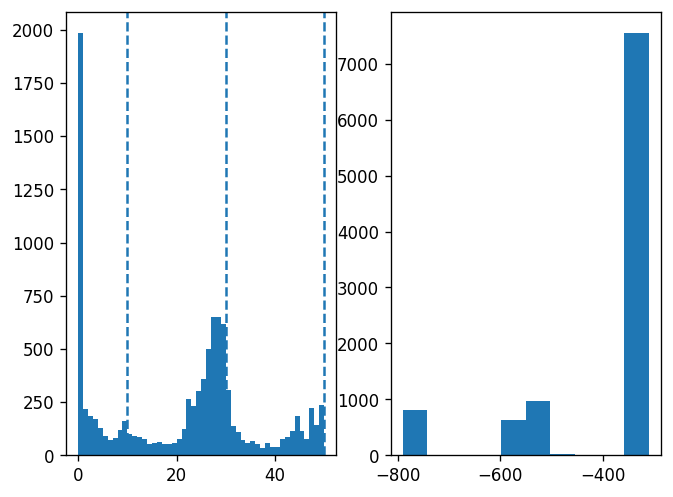

In [26]:
plt.subplot(1,2,1)
plt.axvline(Tramp1, linestyle = '--')
plt.axvline(Tramp2, linestyle = '--')
plt.axvline(Tramp3, linestyle = '--')
plt.hist(time_array, bins = 50, range = (0, 50))
plt.subplot(1,2,2)
plt.hist(Z_array)